In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import importlib
import model_functions
import utils
importlib.reload(model_functions)
importlib.reload(utils)

from utils import discount, plot_cea, gen_cea

from model_functions import load_transition_matrix, gen_risk_matrix, gen_transition_probabilities, run_markov_cohort, \
    run_mc_sim, calculate_outcomes, plot_trace, load_costs, STAGE_ORDER, run_comparison

In [96]:
# GLOBAL initial values
cycle_length = 1/4 # in years
starting_age = 15  # TODO change to 12?
n_years = 100 - starting_age  # simulate until age 100
n_cycles = int(n_years / cycle_length)

In [129]:
tm = load_transition_matrix('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv', "_obs", cycle_length=cycle_length)
rm = gen_risk_matrix(regression_risk=1.56, progression_risk=1)

initial_prevalence = [.628, 0.309, 0.035, 0.016, 0.012, 0,0,0,0,0]

trace = run_markov_cohort(tm, initial_prevalence, n_cycles, starting_age=starting_age, cycle_length=cycle_length)

trace_rm = run_markov_cohort(tm, initial_prevalence, n_cycles, starting_age=starting_age, cycle_length=cycle_length, risk_matrix=rm)


to_state          F0        F1        F2        F3        F4       HCC  \
from_state                                                               
F0          0.983544  0.016119  0.000000  0.000000  0.000000  0.000000   
F1          0.006231  0.976330  0.017102  0.000000  0.000000  0.000000   
F2          0.000000  0.011434  0.973833  0.014395  0.000000  0.000000   
F3          0.000000  0.000000  0.014888  0.972736  0.011187  0.000851   
F4          0.000000  0.000000  0.000000  0.011681  0.961496  0.009587   
HCC         0.000000  0.000000  0.000000  0.000000  0.000000  0.891436   
DC          0.000000  0.000000  0.000000  0.000000  0.000000  0.001738   
LT          0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
post-LT     0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
Death       0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

to_state          DC        LT   post-LT     Death  
from_state                                          
F0   

In [91]:
outcomes = calculate_outcomes(trace, cycle_length, 'SOC')

print('\nIntervention added')
outcomes_rm = calculate_outcomes(trace_rm, cycle_length, 'Semaglutide')


Total LY:  43.51309823612231
Total QALY:  36.080872800547574
Total Cost:  803709.4496782159
Discounted LY:  23.20717262454948
Discounted QALY:  19.767460092453703
Discounted Cost:  377115.7705035754

Intervention added
Total LY:  44.97285301066377
Total QALY:  37.743090701805656
Total Cost:  1039959.4710283497
Discounted LY:  23.640195293263517
Discounted QALY:  20.307236022317742
Discounted Cost:  510630.52530965663


In [121]:
outcomes = calculate_outcomes(trace, cycle_length, 'SOC')

print('\nIntervention added')
outcomes_rm = calculate_outcomes(trace_rm, cycle_length, 'Semaglutide')


Total LY:  43.51309823612231
Total QALY:  36.080872800547574
Total Cost:  803709.4496782159
Discounted LY:  23.20717262454948
Discounted QALY:  19.767460092453703
Discounted Cost:  377115.7705035754

Intervention added
Total LY:  44.10505773018184
Total QALY:  36.790257943483134
Total Cost:  1070835.0363522745
Discounted LY:  23.374514138192367
Discounted QALY:  19.989415960880393
Discounted Cost:  524078.97007178696


In [82]:
(510630 - 377115) / (20.30723 - 19.767)

247144.73465005597

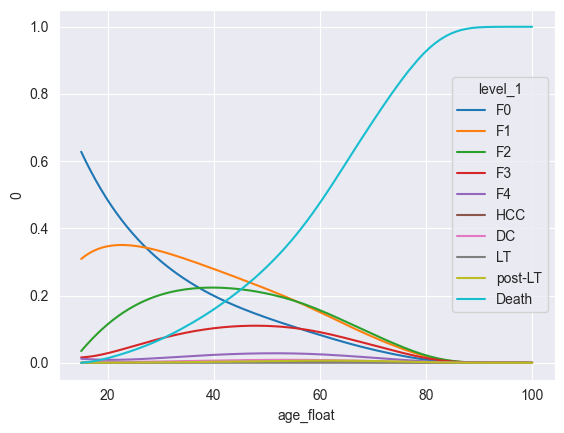

In [122]:

plot_trace(trace)

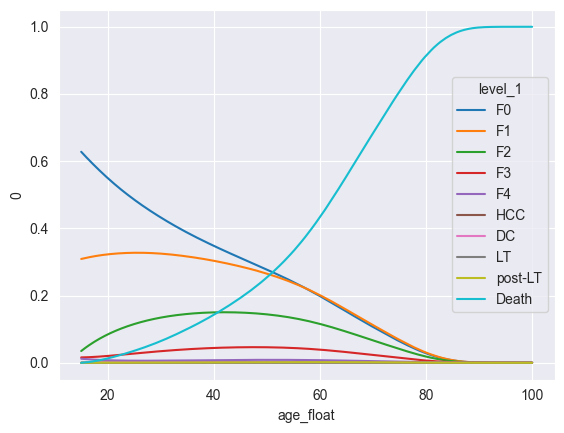

In [94]:

plot_trace(trace_rm)

# Test main comparison

In [ ]:
rr = [1, 1.56]  # relative risk of regression with treatment
pr = [1, 0.6097424116233234] # relative risk of progression with treatment (calculated below)

baseline_tm_suffix = "_trial"

Running model for treatment: SOC
{'transition_suffix': '_trial', 'risk_attenuated_cycles': 6}
Total LY:  42.66622681668631
Total QALY:  35.28136465507282
Total Cost:  933674.6834294496
Discounted LY:  22.85891251756616
Discounted QALY:  19.403789507741067
Discounted Cost:  435714.30798612797
Running model for treatment: Semaglutide
{'transition_suffix': '_trial', 'risk_attenuated_cycles': 6}
Total LY:  42.989316612633786
Total QALY:  35.58494776551193
Total Cost:  939129.8185713931
Discounted LY:  22.988403945270374
Discounted QALY:  19.54267903322325
Discounted Cost:  440015.2707829928


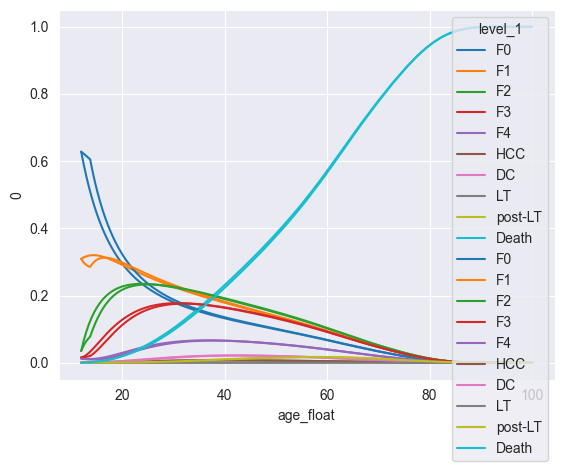

In [187]:
results, traces = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, 
               transition_suffix=baseline_tm_suffix, risk_attenuated_cycles=6)

In [204]:
basic_results = gen_cea(results)

In [205]:
basic_results.to_csv('results/cea_basic_comparison.start_age_12.18_months_tx.csv')

# Compare SOC to Start at 12 to Start at 18

Running model for treatment: SOC
{'transition_suffix': '_trial', 'starting_age': 12, 'risk_attenuated_cycles': 0, 'begin_tx_at_cycle': 0, 'tx_cost_override': 6829}
Total LY:  42.66622681668631
Total QALY:  35.28136465507282
Total Cost:  933674.6834294496
Discounted LY:  22.85891251756616
Discounted QALY:  19.403789507741067
Discounted Cost:  435714.30798612797
Running model for treatment: Semaglutide
{'transition_suffix': '_trial', 'starting_age': 12, 'risk_attenuated_cycles': 30, 'begin_tx_at_cycle': 0, 'tx_cost_override': 6829}
Total LY:  44.09449841202486
Total QALY:  36.62916365576752
Total Cost:  963355.8373818893
Discounted LY:  23.400466413130413
Discounted QALY:  19.98680179311252
Discounted Cost:  459138.3438267878
Running model for treatment: Semaglutide
{'transition_suffix': '_trial', 'starting_age': 12, 'risk_attenuated_cycles': 18, 'begin_tx_at_cycle': 12, 'tx_cost_override': 6829}
Total LY:  43.71809930762528
Total QALY:  36.26792504257056
Total Cost:  948965.4106646095
D

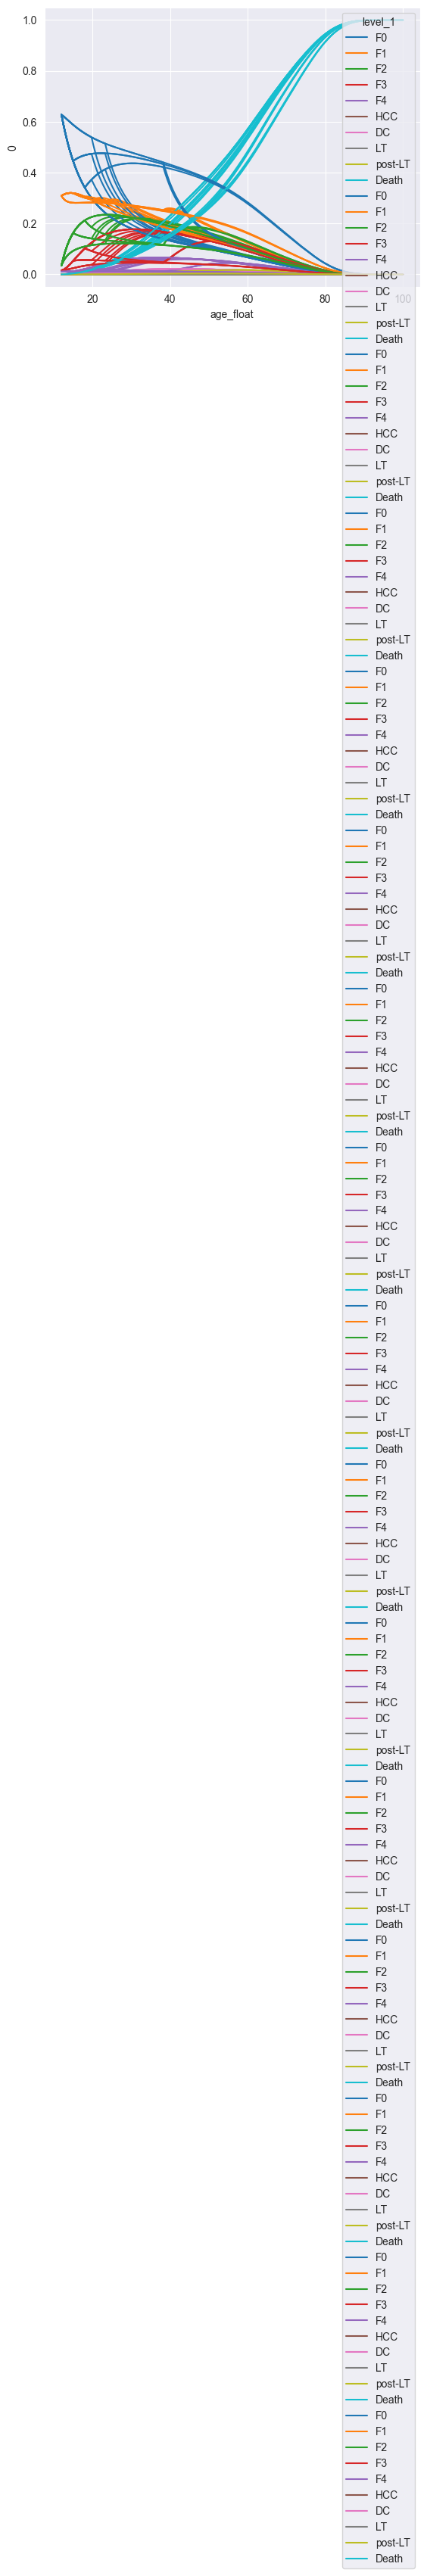

In [42]:
initial_prevalence = [.628, 0.309, 0.035, 0.016, 0.012, 0,0,0,0,0]

rr = [1] + [1.56] * 3  # relative risk of regression with treatment
pr = [1] + [0.6097424116233234] * 3 # relative risk of progression with treatment (calculated below)

baseline_tm_suffix = "_trial"
c_tx = 6829

all_results = []
for len_of_tx in [6, 4*5, 4*20, None]:
    treatments = ['SOC']
    risk_attenuated_cycles = [0]
    begin_tx_at_cycle = [0]
    labels = ['SOC']
    
    for i in [0,3,6]:
        treatments.append('Semaglutide')
        if len_of_tx is not None:
            risk_attenuated_cycles.append(len_of_tx + (6-i)*4)
        else:
            risk_attenuated_cycles.append(None)
        begin_tx_at_cycle.append(i*4)
        labels.append(f'Semaglutide-start_{12 + i}-len_{len_of_tx/4 if len_of_tx is not None else 88}')
    
    results_, trace_ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
                   initial_prevalence, treatments, rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
                   starting_age=12, risk_attenuated_cycles=risk_attenuated_cycles, labels=labels,
                                                 begin_tx_at_cycle=begin_tx_at_cycle, tx_cost_override=c_tx, plot=False)
    all_results.append(results_)

In [98]:
all_results_df = pd.concat([gen_cea(res) for res in all_results])
# Split the index and handle SOC separately
split_data = all_results_df.index.str.split('-', expand=True)

# Extract treatment name (first part)
all_results_df['Tx'] = split_data.get_level_values(0)

# For non-SOC rows, extract start and len
all_results_df['Start_age'] = split_data.get_level_values(1).str.replace('start_', '')
all_results_df['length_tx_past_18'] = split_data.get_level_values(2).str.replace('len_', '')

all_results_df.reset_index(inplace=True)
# For SOC rows, set start_12 and forward-fill len from next row
all_results_df.loc[all_results_df['Tx'] == 'SOC', 'Start_age'] = '12_'
all_results_df.loc[all_results_df['Tx'] == 'SOC', 'length_tx_past_18'] = \
    all_results_df['length_tx_past_18'].shift(-1)


In [101]:
all_results_df.to_csv('cea_start_tx_age_comparison_results.same_end_tx_age.csv', index=False)

In [195]:
all_results_df = pd.read_csv('results/cea_start_tx_age_comparison_results.same_end_tx_age.csv')


In [196]:
all_results_df

,index,QALY,Cost,Delta_Cost,Delta_QALY,ICER,Tx,Start_age,length_tx_past_18
0,SOC,19.403790,435714.307986,435714.307986,19.403790,22455.114132,SOC,12_,1.5
1,Semaglutide-start_18-len_1.5,19.580869,437317.531290,1603.223303,0.177079,9053.716910,Semaglutide,18,1.5
2,Semaglutide-start_15-len_1.5,19.823342,446178.633438,8861.102148,0.242474,36544.594886,Semaglutide,15,1.5
3,Semaglutide-start_12-len_1.5,19.986802,459138.343827,12959.710389,0.163460,79283.877265,Semaglutide,12,1.5
4,SOC,19.403790,435714.307986,435714.307986,19.403790,22455.114132,SOC,12_,5.0
5,Semaglutide-start_18-len_5.0,19.871052,443631.032082,7916.724096,0.467262,16942.781962,Semaglutide,18,5.0
6,Semaglutide-start_15-len_5.0,20.069535,454101.480235,10470.448153,0.198483,52752.314587,Semaglutide,15,5.0
7,Semaglutide-start_12-len_5.0,20.207966,467998.062635,13896.582400,0.138431,100386.505028,Semaglutide,12,5.0
8,SOC,19.403790,435714.307986,435714.307986,19.403790,22455.114132,SOC,12_,20.0
9,Semaglutide-start_18-len_20.0,20.551838,466733.641258,31019.333272,1.148049,27019.179423,Semaglutide,18,20.0


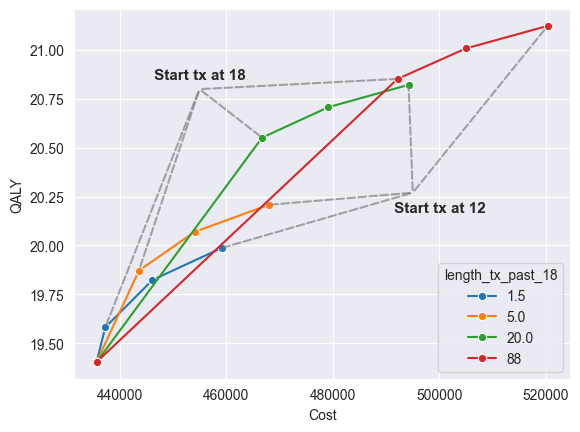

In [94]:
fig = sns.lineplot(data=all_results_df, x='Cost', y='QALY', marker='o', hue='length_tx_past_18')

# Get all the 18 year start points
age_18_points = all_results_df[all_results_df['Start_age'] == '18']

# Single text annotation positioned centrally
text_x = 455000
text_y = 20.8

plt.text(text_x, text_y + 0.05, 'Start tx at 18', fontsize=11, ha='center', fontweight='bold')

# Draw lines from text to each point
for _, row in age_18_points.iterrows():
    plt.annotate('',
                 xy=(row['Cost'], row['QALY']),
                 xytext=(text_x, text_y),
                 arrowprops=dict(arrowstyle='-', lw=1.5, color='gray', linestyle='--', alpha=0.7))

# Repeat for 12 year start
age_12_points = all_results_df[all_results_df['Start_age'] == '12']
text_x = 495000
text_y = 20.27

plt.text(text_x + 5000, text_y - 0.1, 'Start tx at 12', fontsize=11, ha='center', fontweight='bold')

for _, row in age_12_points[age_12_points['index'] != 'SOC'].iterrows():
    plt.annotate('',
                 xy=(row['Cost'], row['QALY']),
                 xytext=(text_x, text_y),
                 arrowprops=dict(arrowstyle='-', lw=1.5, color='gray',  linestyle='--', alpha=0.7))

# plt.tight_layout()

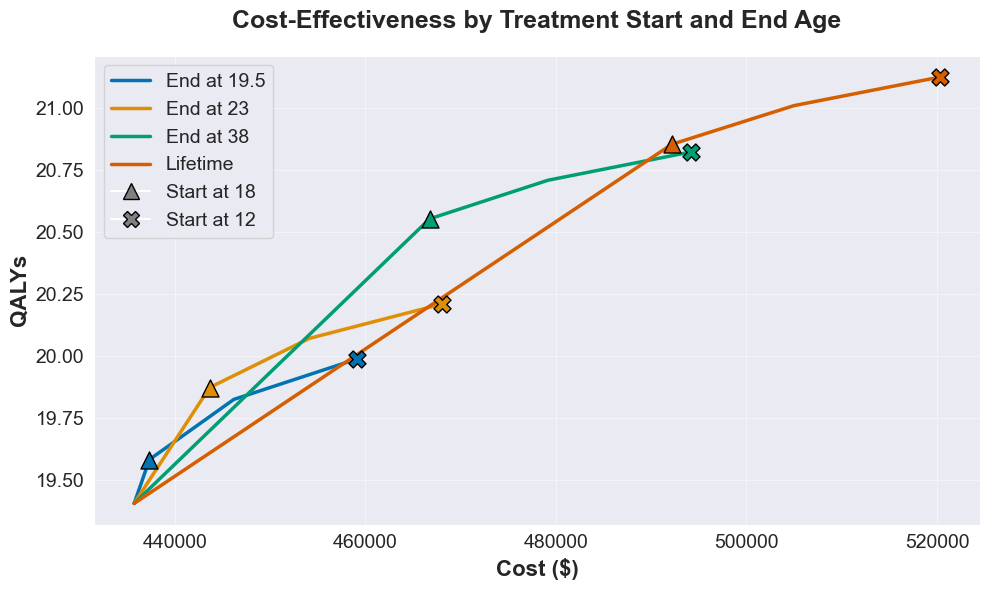

In [167]:
fig, ax = plt.subplots(figsize=(10, 6))

# Change lineplot to have thicker lines
sns.lineplot(data=all_results_df, x='Cost', y='QALY', hue='length_tx_past_18', 
             ax=ax, linewidth=2.5, palette='colorblind')

# Add markers for different start ages
age_18_points = all_results_df[all_results_df['Start_age'] == '18']
age_12_points = all_results_df[all_results_df['Start_age'] == '12']

# Plot markers for each duration group
for duration in all_results_df['length_tx_past_18'].unique():
    age_18_subset = age_18_points[age_18_points['length_tx_past_18'] == duration]
    age_12_subset = age_12_points[age_12_points['length_tx_past_18'] == duration]
    
    color = ax.lines[list(all_results_df['length_tx_past_18'].unique()).index(duration)].get_color()
    
    ax.scatter(age_18_subset['Cost'], age_18_subset['QALY'], 
               marker='^', s=150, color=color, edgecolor='black', linewidth=1, zorder=10)
    ax.scatter(age_12_subset['Cost'], age_12_subset['QALY'], 
               marker='X', s=150, color=color, edgecolor='black', linewidth=1, zorder=10)

# Add title and format axes
ax.set_title('Cost-Effectiveness by Treatment Start and End Age', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Cost ($)', fontsize=16, fontweight='bold')
ax.set_ylabel('QALYs', fontsize=16, fontweight='bold')
ax.tick_params(axis='both', labelsize=14)

# Update legend
from matplotlib.lines import Line2D

marker_legend = [Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', 
                        markersize=12, label='Start at 18', markeredgewidth=1, markeredgecolor='black'),
                 Line2D([0], [0], marker='X', color='w', markerfacecolor='gray', 
                        markersize=12, label='Start at 12', markeredgewidth=1, markeredgecolor='black')]
# After creating the legend, update the labels
handles, labels = ax.get_legend_handles_labels()

# Format the duration labels
formatted_labels = []
for label in labels:
    try:
        val = float(label)
        if val == 88:
            formatted_labels.append('Lifetime')
        elif val == int(val):
            formatted_labels.append(f'End at {int(val) + 18}')
        else:
            formatted_labels.append(f'End at {val + 18}')
    except ValueError:
        formatted_labels.append(label)

# Update legend with formatted labels
ax.legend(handles=handles + marker_legend, 
          labels=formatted_labels + ['Start at 18', 'Start at 12'],
          loc='best', fontsize=14, title_fontsize=14)

# Grid
ax.grid(True, alpha=0.6, linestyle='-', linewidth=0.6)
ax.set_axisbelow(True)

lines = ax.get_lines()

plt.tight_layout()
fig.savefig('cea_start_age_comparison.same_end_tx_age.png', dpi=300)

plt.show()

## Do the same but with the same length of treatment instead of same end age

In [123]:
initial_prevalence = [.628, 0.309, 0.035, 0.016, 0.012, 0,0,0,0,0]

rr = [1] + [1.56] * 3  # relative risk of regression with treatment
pr = [1] + [0.6097424116233234] * 3 # relative risk of progression with treatment (calculated below)

baseline_tm_suffix = "_trial"
c_tx = 6829

all_results = []
for len_of_tx in [6, 4*5, 4*20, 4*82]:
    treatments = ['SOC']
    risk_attenuated_cycles = [0]
    begin_tx_at_cycle = [0]
    labels = ['SOC']
    
    for i in [0,3,6]:
        treatments.append('Semaglutide')
        if len_of_tx is not None:
            risk_attenuated_cycles.append(len_of_tx)
        else:
            risk_attenuated_cycles.append(None)
        begin_tx_at_cycle.append(i*4)
        labels.append(f'Semaglutide-start_{12 + i}-len_{len_of_tx/4 if len_of_tx is not None else 88}')
    
    results_, trace_ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
                   initial_prevalence, treatments, rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
                   starting_age=12, risk_attenuated_cycles=risk_attenuated_cycles, labels=labels,
                                                 begin_tx_at_cycle=begin_tx_at_cycle, tx_cost_override=c_tx, plot=False)
    all_results.append(results_)

Running model for treatment: SOC
{'transition_suffix': '_trial', 'starting_age': 12, 'risk_attenuated_cycles': 0, 'begin_tx_at_cycle': 0, 'tx_cost_override': 6829, 'plot': False}
Total LY:  42.66622681668631
Total QALY:  35.28136465507282
Total Cost:  933674.6834294496
Discounted LY:  22.85891251756616
Discounted QALY:  19.403789507741067
Discounted Cost:  435714.30798612797
Running model for treatment: Semaglutide
{'transition_suffix': '_trial', 'starting_age': 12, 'risk_attenuated_cycles': 6, 'begin_tx_at_cycle': 0, 'tx_cost_override': 6829, 'plot': False}
Total LY:  42.989316612633786
Total QALY:  35.58494776551193
Total Cost:  939129.8185713931
Discounted LY:  22.988403945270374
Discounted QALY:  19.54267903322325
Discounted Cost:  440015.2707829928
Running model for treatment: Semaglutide
{'transition_suffix': '_trial', 'starting_age': 12, 'risk_attenuated_cycles': 6, 'begin_tx_at_cycle': 12, 'tx_cost_override': 6829, 'plot': False}
Total LY:  43.07415800968573
Total QALY:  35.663

In [129]:
all_results_df = pd.concat([gen_cea(res) for res in all_results])
# Split the index and handle SOC separately
split_data = all_results_df.index.str.split('-', expand=True)

# Extract treatment name (first part)
all_results_df['Tx'] = split_data.get_level_values(0)

# For non-SOC rows, extract start and len
all_results_df['Start_age'] = split_data.get_level_values(1).str.replace('start_', '')
all_results_df['length_tx_past_18'] = split_data.get_level_values(2).str.replace('len_', '')

all_results_df.reset_index(inplace=True)
# For SOC rows, set start_12 and forward-fill len from next row
all_results_df.loc[all_results_df['Tx'] == 'SOC', 'Start_age'] = '12_'
all_results_df.loc[all_results_df['Tx'] == 'SOC', 'length_tx_past_18'] = \
    all_results_df['length_tx_past_18'].shift(-1)


In [192]:
all_results_df

,index,QALY,Cost,Delta_Cost,Delta_QALY,ICER,Tx,Start_age,length_tx_past_18
0,SOC,19.403790,435714.307986,435714.307986,19.403790,22455.114132,SOC,12_,1.5
1,Semaglutide-start_18-len_1.5,19.580869,437317.531290,1603.223303,0.177079,9053.716910,Semaglutide,18,1.5
2,Semaglutide-start_15-len_1.5,19.571268,438733.729640,1416.198350,-0.009600,-147513.800033,Semaglutide,15,1.5
3,Semaglutide-start_12-len_1.5,19.542679,440015.270783,1281.541143,-0.028589,-44826.299037,Semaglutide,12,1.5
4,SOC,19.403790,435714.307986,435714.307986,19.403790,22455.114132,SOC,12_,5.0
5,Semaglutide-start_18-len_5.0,19.871052,443631.032082,7916.724096,0.467262,16942.781962,Semaglutide,18,5.0
6,Semaglutide-start_15-len_5.0,19.861476,447362.059667,3731.027585,-0.009576,-389635.622675,Semaglutide,15,5.0
7,Semaglutide-start_12-len_5.0,19.810414,451870.103857,4508.044190,-0.051062,-88285.988410,Semaglutide,12,5.0
8,SOC,19.403790,435714.307986,435714.307986,19.403790,22455.114132,SOC,12_,20.0
9,Semaglutide-start_18-len_20.0,20.551838,466733.641258,31019.333272,1.148049,27019.179423,Semaglutide,18,20.0


In [142]:
all_results_df.to_csv('cea_start_tx_age_comparison_results.same_tx_duration.csv', index=False)

In [191]:
all_results_df = pd.read_csv('results/cea_start_tx_age_comparison_results.same_tx_duration.csv')


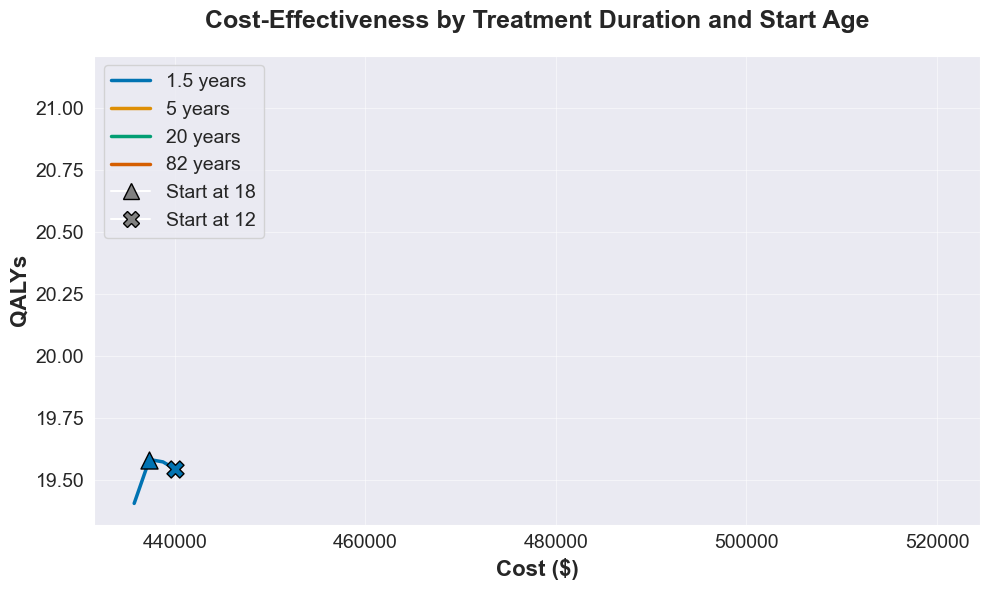

In [172]:
fig, ax = plt.subplots(figsize=(10, 6))

# Change lineplot to have thicker lines
sns.lineplot(data=all_results_df, x='Cost', y='QALY', hue='length_tx_past_18', 
             ax=ax, linewidth=2.5, palette='colorblind')

# Add markers for different start ages
age_18_points = all_results_df[all_results_df['Start_age'] == '18']
age_12_points = all_results_df[all_results_df['Start_age'] == '12']

# Plot markers for each duration group
for duration in [1.5]: #all_results_df['length_tx_past_18'].unique():
    age_18_subset = age_18_points[age_18_points['length_tx_past_18'] == duration]
    age_12_subset = age_12_points[age_12_points['length_tx_past_18'] == duration]
    
    color = ax.lines[list(all_results_df['length_tx_past_18'].unique()).index(duration)].get_color()
    
    ax.scatter(age_18_subset['Cost'], age_18_subset['QALY'], 
               marker='^', s=150, color=color, edgecolor='black', linewidth=1, zorder=10)
    ax.scatter(age_12_subset['Cost'], age_12_subset['QALY'], 
               marker='X', s=150, color=color, edgecolor='black', linewidth=1, zorder=10)

# Add title and format axes
ax.set_title('Cost-Effectiveness by Treatment Duration and Start Age', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Cost ($)', fontsize=16, fontweight='bold')
ax.set_ylabel('QALYs', fontsize=16, fontweight='bold')
ax.tick_params(axis='both', labelsize=14)

# Update legend
from matplotlib.lines import Line2D

marker_legend = [Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', 
                        markersize=12, label='Start at 18', markeredgewidth=1, markeredgecolor='black'),
                 Line2D([0], [0], marker='X', color='w', markerfacecolor='gray', 
                        markersize=12, label='Start at 12', markeredgewidth=1, markeredgecolor='black')]
# After creating the legend, update the labels
handles, labels = ax.get_legend_handles_labels()

# Format the duration labels
formatted_labels = []
for label in labels:
    try:
        val = float(label)
        if val == int(val):
            formatted_labels.append(f'{int(val)} years')
        else:
            formatted_labels.append(f'{val} years')
    except ValueError:
        formatted_labels.append(label)

# Update legend with formatted labels
ax.legend(handles=handles + marker_legend, 
          labels=formatted_labels + ['Start at 18', 'Start at 12'],
          loc='best', fontsize=14, title_fontsize=14)

# Grid
ax.grid(True, alpha=0.6, linestyle='-', linewidth=0.6)
ax.set_axisbelow(True)

lines = ax.get_lines()

# Hide lines for durations other than 1.5
for line in lines:
    # Check the line's data or label to determine if it's 1.5
    label = line.get_label()
    if label not in ['1.5', '_child0']:  # Adjust based on actual labels
        line.set_visible(False)

plt.tight_layout()
fig.savefig('cea_start_age_comparison.same_tx_duration.only_1_5.png', dpi=300)
# fig.savefig('cea_start_age_comparison.same_tx_duration.png', dpi=300)

plt.show()

### Get trace plot

Running model for treatment: SOC
{'transition_suffix': '_trial', 'starting_age': 12, 'risk_attenuated_cycles': 0, 'begin_tx_at_cycle': 0, 'tx_cost_override': 6829, 'plot': True}
Total LY:  42.66622681668631
Total QALY:  35.28136465507282
Total Cost:  933674.6834294496
Discounted LY:  22.85891251756616
Discounted QALY:  19.403789507741067
Discounted Cost:  435714.30798612797
Running model for treatment: Semaglutide
{'transition_suffix': '_trial', 'starting_age': 12, 'risk_attenuated_cycles': 6, 'begin_tx_at_cycle': 0, 'tx_cost_override': 6829, 'plot': True}
Total LY:  42.989316612633786
Total QALY:  35.58494776551193
Total Cost:  939129.8185713931
Discounted LY:  22.988403945270374
Discounted QALY:  19.54267903322325
Discounted Cost:  440015.2707829928
Running model for treatment: Semaglutide
{'transition_suffix': '_trial', 'starting_age': 12, 'risk_attenuated_cycles': 6, 'begin_tx_at_cycle': 12, 'tx_cost_override': 6829, 'plot': True}
Total LY:  43.07415800968573
Total QALY:  35.663463

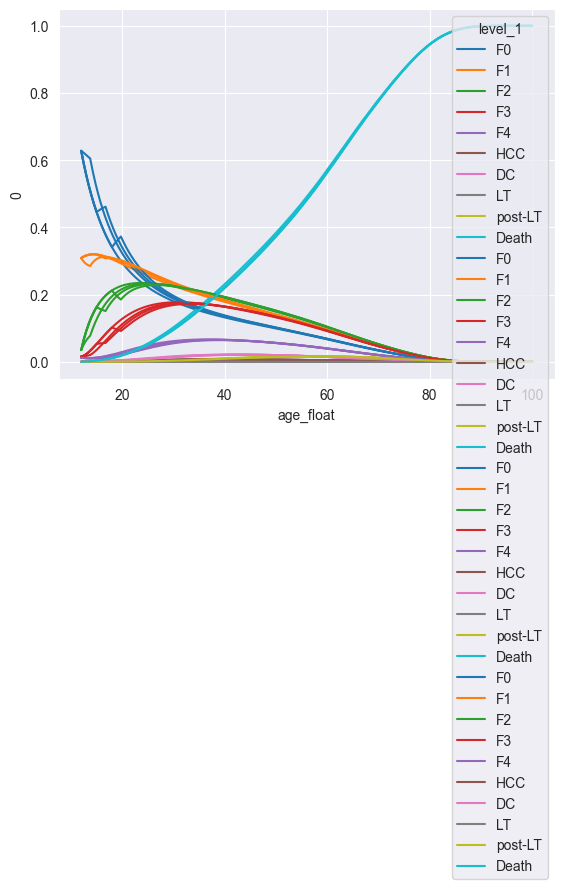

In [173]:
len_of_tx = 6
treatments = ['SOC']
risk_attenuated_cycles = [0]
begin_tx_at_cycle = [0]
labels = ['SOC']

for i in [0,3,6]:
    treatments.append('Semaglutide')
    if len_of_tx is not None:
        risk_attenuated_cycles.append(len_of_tx)
    else:
        risk_attenuated_cycles.append(None)
    begin_tx_at_cycle.append(i*4)
    labels.append(f'Semaglutide-start_{12 + i}-len_{len_of_tx/4 if len_of_tx is not None else 88}')

results_, trace_ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, treatments, rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
               starting_age=12, risk_attenuated_cycles=risk_attenuated_cycles, labels=labels,
                                             begin_tx_at_cycle=begin_tx_at_cycle, tx_cost_override=c_tx, plot=True)

In [175]:
trace_.keys()

dict_keys(['SOC', 'Semaglutide-start_12-len_1.5', 'Semaglutide-start_15-len_1.5', 'Semaglutide-start_18-len_1.5'])

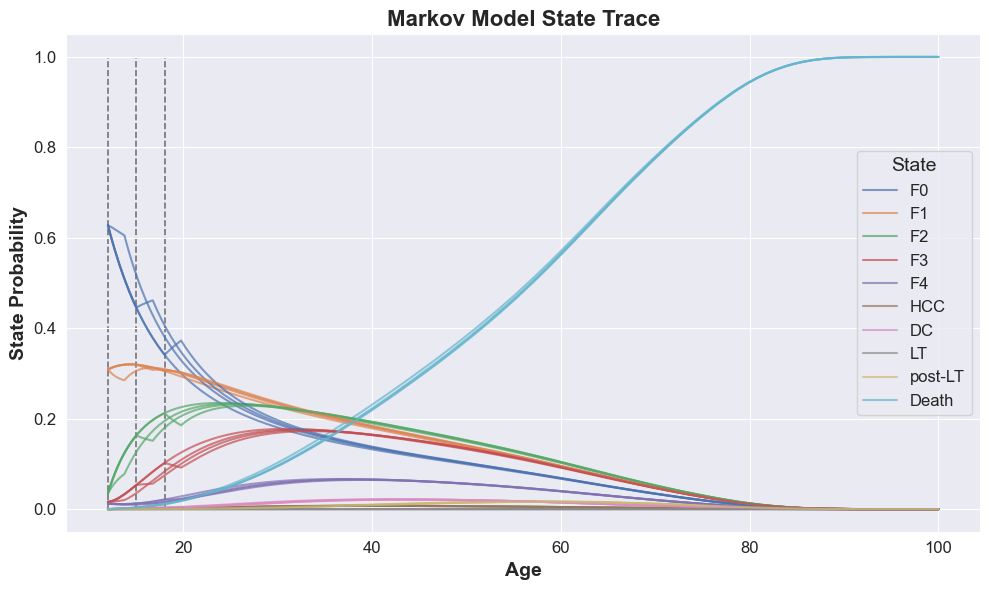

In [186]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot first key to establish legend
first_key = list(trace_.keys())[0]
sns.lineplot(data=trace_[first_key].drop(columns='age').set_index('age_float').stack().reset_index(), 
             x='age_float', y=0, hue='level_1', ax=ax, alpha=0.7, palette='deep')

# Plot remaining keys without adding to legend
for key in list(trace_.keys())[1:]:
    sns.lineplot(data=trace_[key].drop(columns='age').set_index('age_float').stack().reset_index(), 
                 x='age_float', y=0, hue='level_1', ax=ax, alpha=0.7, legend=False, palette='deep')

ax.vlines(x=12, ymin=0, ymax=1, colors='black', linestyles='--', linewidth=1.2, alpha=0.5, zorder=-5)
ax.vlines(x=15, ymin=0, ymax=1, colors='black', linestyles='--', linewidth=1.2, alpha=0.5, zorder=-5)

ax.vlines(x=18, ymin=0, ymax=1, colors='black', linestyles='--', linewidth=1.2, alpha=0.5, zorder=-5)


# Better labels
ax.set_xlabel('Age', fontsize=14, fontweight='bold')
ax.set_ylabel('State Probability', fontsize=14, fontweight='bold')
ax.set_title('Markov Model State Trace', fontsize=16, fontweight='bold')
ax.tick_params(axis='both', labelsize=12)
ax.legend(title='State', fontsize=12, title_fontsize=14)

plt.tight_layout()
fig.savefig('markov_trace_start_age_comparison.same_tx_duration.len_1_5.png', dpi=300)